<a href="https://colab.research.google.com/github/EAduAgyei/EAduAgyei/blob/main/MyProject1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1
# Malignant Lung Nodule Detection

In this project, you will develop a deep learning model to classify lung nodules as benign or malignant from 3D CT scans, utilizing the LUNA16 dataset. This task involves data preprocessing, model design, training, and evaluation, offering hands-on experience with medical image analysis and deep learning in PyTorch.

## 1. Load Annotation Data
As the first step, we will need to load the processed annotation data created in class. Please review the "DataPreparation" notebook for details.

1.1 Upload the annotation CSV file to the current Colab environment.

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (5).json


{'kaggle (5).json': b'{"username":"euniceaduagyei","key":"50d8abf2a1263c3bf9b1a08ddedf6def"}'}

In [ ]:
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [ ]:
! ls ~/.kaggle

kaggle.json


In [ ]:
! chmod 600 ~/.kaggle/kaggle.json

In [ ]:
! kaggle datasets list -s 'luna16'

ref                                      title                                                 size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------  ---------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
avc0706/luna16                           Luna16                                         34507100408  2020-11-19 04:17:45.270000           5119         54  0.64705884       
fanbyprinciple/luna-lung-cancer-dataset  Luna16 Lung Cancer Dataset                       346449017  2021-03-14 03:54:34.790000           9101         79  0.8235294        
amirrezamousavi/luna16                   luna16subset0to5                               40781021037  2022-09-17 11:55:34.570000            471          7  0.7647059        
kmader/lungnodemalignancy                Lung Nodule Malignancy                            99475568  2017-09-21 15:36:33.903000        

In [ ]:
! kaggle datasets download -d 'fanbyprinciple/luna-lung-cancer-dataset'

Dataset URL: https://www.kaggle.com/datasets/fanbyprinciple/luna-lung-cancer-dataset
License(s): CC-BY-SA-3.0
luna-lung-cancer-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
! unzip luna-lung-cancer-dataset.zip -d luna16

Archive:  luna-lung-cancer-dataset.zip
replace luna16/annotations.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: luna16/annotations.csv  
  inflating: luna16/candidates.csv   
  inflating: luna16/candidates_V2/candidates_V2.csv  
  inflating: luna16/evaluationScript/evaluationScript/NoduleFinding.py  
  inflating: luna16/evaluationScript/evaluationScript/annotations/annotations.csv  
  inflating: luna16/evaluationScript/evaluationScript/annotations/annotations_excluded.csv  
  inflating: luna16/evaluationScript/evaluationScript/annotations/seriesuids.csv  
  inflating: luna16/evaluationScript/evaluationScript/exampleFiles/evaluation/CADAnalysis.txt  
  inflating: luna16/evaluationScript/evaluationScript/exampleFiles/evaluation/FROC_sampleSubmission.png  
  inflating: luna16/evaluationScript/evaluationScript/exampleFiles/evaluation/froc_gt_prob_vectors_sampleSubmission.csv  
  inflating: luna16/evaluationScript/evaluationScript/exampleFiles/evaluation/froc_sampleSubmission.tx

In [ ]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
annotations = pd.read_csv("luna16/annotations.csv")

In [ ]:
annotations.head()

,seriesuid,coordX,coordY,coordZ,diameter_mm
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-128.699421,-175.319272,-298.387506,5.651471
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,103.783651,-211.925149,-227.121250,4.224708
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...,69.639017,-140.944586,876.374496,5.786348
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,-24.013824,192.102405,-391.081276,8.143262
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,2.441547,172.464881,-405.493732,18.545150


1.2 Load the `candidates_processed.csv` file as a data frame. Display the first 5 rows.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
! ls drive/MyDrive/*.csv

drive/MyDrive/candidates_processed.csv	drive/MyDrive/ct_info.csv


In [ ]:
data = pd.read_csv("drive/MyDrive/candidates_processed.csv")
data.head()

,seriesuid,coordX,coordY,coordZ,class,index,row,col
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031...,-66.383107,57.143607,-60.885862,0,110,331,173
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031...,-132.856859,23.813034,-274.350845,0,24,287,86
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031...,84.770000,66.170000,-249.880000,0,34,343,371
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031...,134.805360,29.696241,-268.116009,0,27,295,437
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031...,-87.092676,41.722383,-208.831394,0,51,311,146


1.3 Display the number of class 0 (benign) records and the number of class 1 (malignant) records. Your results should indicate that the two classes are highly imbalanced.

In [ ]:
candidates = pd.read_csv('luna16/candidates_V2/candidates_V2.csv')

In [ ]:
candidates.head()

,seriesuid,coordX,coordY,coordZ,class
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,68.420000,-74.480000,-288.700000,0
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-95.209361,-91.809406,-377.426350,0
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-24.766755,-120.379294,-273.361539,0
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-63.080000,-65.740000,-344.240000,0
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,52.946688,-92.688873,-241.067872,0


In [ ]:
! pip install SimpleITK

In [ ]:
import torch
import SimpleITK as sitk
import numpy as np

In [ ]:
num_nodules = 5000

chunks = torch.zeros([num_nodules, 32, 48, 48])
labels = torch.zeros([num_nodules])

In [ ]:
from sklearn.model_selection import train_test_split
chunks_train, chunks_test, labels_train, labels_test = train_test_split(chunks, labels, test_size=0.2)
print(labels_train.shape)
print(labels_test.shape)

torch.Size([4000])
torch.Size([1000])


## 2. Find Nodule Locations
In the annotation dataset, the center of each identified lung nodule is marked with its 3D coordinates. We need to convert these coordinates into three indices to identify the specific subarray in each CT scan tensor that corresponds to the nodule.

Please follow the steps outlined in the LUNA16DataPreparation notebook to generate a CSV file named `candidates_processed.csv`, which will store the indices for the center of each lung nodule.

2.1 Load the `subset0.zip` from Google Drive using the file ID '1OFa8UhDvCrcTj1VkFLa7RjifEqMD4TAa'. Extract the zip file to reveal the .mhd and .raw files.

In [ ]:
import torch.nn as nn
import torch.optim as optim

In [ ]:
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

In [ ]:
id='1OFa8UhDvCrcTj1VkFLa7RjifEqMD4TAa'
downloaded = drive.CreateFile({'id': id})
downloaded.GetContentFile('subset0.zip')

In [ ]:
! unzip subset0.zip

Archive:  subset0.zip
replace subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031515062000744821260.mhd? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031515062000744821260.mhd  
  inflating: subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031515062000744821260.raw  
  inflating: subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896446896160048741492.mhd  
  inflating: subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896446896160048741492.raw  
  inflating: subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524522225658609808059.mhd  
  inflating: subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524522225658609808059.raw  
  inflating: subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.111172165674661221381920536987.mhd  
  inflating: subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.111172165674661221381920536987.raw  
  inflating: subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.122763913896761494371822656720.mhd  
  inflating: subset0/1.3

2.2 Use `matplotlib` library to visualize the first malignant lung nodule in the dataset. Create an image to display a 2D slice from each of its three dimensions.

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
data_positive = data[data['class'] == 1]
#print("Total number of positive instances:", len(data_positive))
#data_positive.head(10)

In [ ]:
nodule_index = data_positive.index[1]
uid = data_positive.loc[nodule_index, 'seriesuid']

mhd_path = "subset0/" + uid + ".mhd"
ct_mhd = sitk.ReadImage(mhd_path)
ct_a = np.array(sitk.GetArrayFromImage(ct_mhd), dtype=np.float32)
ct_a = ct_a.clip(-1000, 1000, ct_a)

index, row, col = data.loc[nodule_index, ["index", "row", "col"]]
ct_chunk = torch.zeros([32, 48, 48])
chunk = ct_a[(index-16):(index+16), (row-24):(row+24), (col-24):(col+24)]
chunk_indices, chunk_rows, chunk_cols = chunk.shape
ct_chunk[:chunk_indices, :chunk_rows, :chunk_cols] = torch.tensor(chunk)
label = data.loc[nodule_index, 'class']

ct_chunk.shape, label

(torch.Size([32, 48, 48]), np.int64(1))

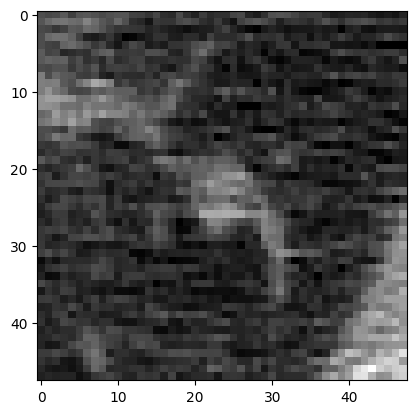

In [ ]:
plt.imshow(ct_chunk[16, :, :], cmap='gray')
plt.show()

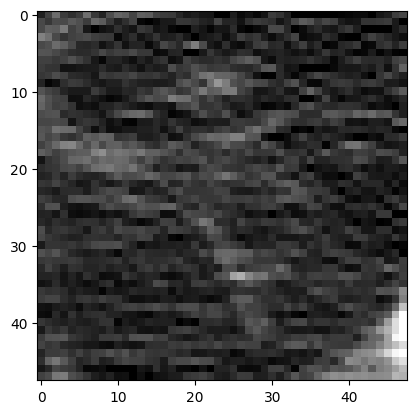

In [ ]:
plt.imshow(ct_chunk[8, :, :], cmap='gray')
plt.show()

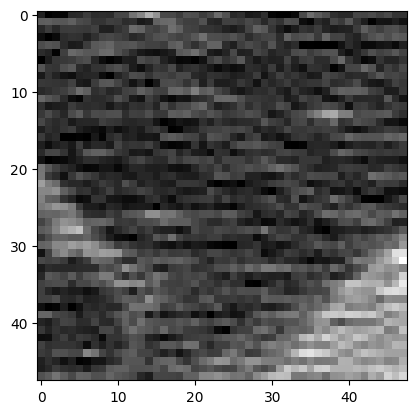

In [ ]:
plt.imshow(ct_chunk[24, :, :], cmap='gray')
plt.show()

## 3. Create Data Tensors

The neural network model we will build with PyTorch requires the data to be presented in the form of a torch tensor. The input tensor should be 4-dimensional, with the dimensions representing the nodule index, channel, row, and column, respectively.

3.1 Write a double for-loop to extract the CT scan data for **the first 5,000*** nodules:
- The outer for loop goes through all the distince seriesuid's.
- For each iteration of the outer loop, load the corresponding CT-scan file and create a torch tensor to represent the scan.
- Create an inner-loop that goes through the nodules corresponding to the seriesuid:
    - Load the (index, row, col) tuple of this nodule from the data frame.
    - Extract a 32x48x48 chunk centered at the (index, row, col). If the nodule is near the edge of the image and there is not enough indices to extract, please pad with zeros to keep the overall shape unchanged.
    - Use a 4D tensor to contain all the 32x48x48 chunks. The first dimension of the 4D tensor is the index of nodule.

You may modify the above procedure as you like. Make sure that you are able to obtain a 4D tensor that contains all nodule data. **Display the shape of the 4D tensor.** The shape of the tensor should be (5000, 32, 48, 48).

**Remark** Due to the memory limit, it is impossible to load all nodule images into simultanously. Therefore, the number of nodules required in this section is reduced to 5,000. Feel free to adjust this number to prevent the out-of-memory error.

In [ ]:
num_nodules = 5000

chunks = torch.zeros([num_nodules, 32, 48, 48])
labels = torch.zeros([num_nodules])

In [ ]:
ids = data['seriesuid'].unique()
count = 0

for seriesuid in ids:

    mhd_path = "subset0/" + seriesuid + ".mhd"
    ct_mhd = sitk.ReadImage(mhd_path)
    ct_a = np.array(sitk.GetArrayFromImage(ct_mhd), dtype=np.float32)
    ct_a = ct_a.clip(-1000, 1000, ct_a)

    condition = (data['seriesuid'] == seriesuid)
    indices = data[condition].index

    for nodule_index in indices:


        index, row, col = data.loc[nodule_index, ["index", "row", "col"]]

        ct_chunk = torch.zeros([32, 48, 48])
        chunk = ct_a[(index-16):(index+16), (row-24):(row+24), (col-24):(col+24)]
        chunk_indices, chunk_rows, chunk_cols = chunk.shape
        ct_chunk[:chunk_indices, :chunk_rows, :chunk_cols] = torch.tensor(chunk)

        chunks[count, :, : :] = ct_chunk

        labels[count] = data.loc[nodule_index, "class"]

        count += 1


        if count % 100 == 0:
            print("Number of nodules constructed:", count)


        if count == num_nodules:
            break

    if count == num_nodules:
        break

Number of nodules constructed: 100
Number of nodules constructed: 200
Number of nodules constructed: 300
Number of nodules constructed: 400
Number of nodules constructed: 500
Number of nodules constructed: 600
Number of nodules constructed: 700
Number of nodules constructed: 800
Number of nodules constructed: 900
Number of nodules constructed: 1000
Number of nodules constructed: 1100
Number of nodules constructed: 1200
Number of nodules constructed: 1300
Number of nodules constructed: 1400
Number of nodules constructed: 1500
Number of nodules constructed: 1600
Number of nodules constructed: 1700
Number of nodules constructed: 1800
Number of nodules constructed: 1900
Number of nodules constructed: 2000
Number of nodules constructed: 2100
Number of nodules constructed: 2200
Number of nodules constructed: 2300
Number of nodules constructed: 2400
Number of nodules constructed: 2500
Number of nodules constructed: 2600
Number of nodules constructed: 2700
Number of nodules constructed: 2800
N

In [ ]:
chunks.shape

torch.Size([5000, 32, 48, 48])

3.2 Create a 1D tensor to contain all the class information.

In [ ]:
tnsr = torch.tensor(range(5000))
tnsr = torch.unsqueeze(tnsr, 1)
print(tnsr)
print(tnsr.shape)

tensor([[   0],
        [   1],
        [   2],
        ...,
        [4997],
        [4998],
        [4999]])
torch.Size([5000, 1])


In [ ]:
t = torch.squeeze(tnsr)
print(t)

tensor([   0,    1,    2,  ..., 4997, 4998, 4999])


3.3 Split the 4D tensor into a training set and a test set. Display their shapes.

In [ ]:
from sklearn.model_selection import train_test_split
chunks_train, chunks_test, labels_train, labels_test = train_test_split(chunks, labels, test_size=0.2)
print(chunks_train.shape)
print(chunks_test.shape)

torch.Size([4000, 32, 48, 48])
torch.Size([1000, 32, 48, 48])


## 4. Model Design and Implementation

4.1 Design a neural network model with only a flatten layer and two dense layers for classifying lung nodules. You may experiment with different sizes for the hidden layers to improve the training results.

In [ ]:
dataset = torch.utils.data.TensorDataset(chunks_train, labels_train)

In [ ]:
train_loader = torch.utils.data.DataLoader(dataset, batch_size= 100, shuffle=True)

In [ ]:
device = (torch.device('cuda') if torch.cuda.is_available()
          else torch.device('cpu'))

In [ ]:
class NeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(73728, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        out = self.flatten(x)

        out = self.fc1(out)

        out = self.fc2(out)
        return out

In [ ]:
model = NeuralNet().to(device)

4.2 Create an object to represent the loss function.

In [ ]:
loss_fn = nn.CrossEntropyLoss()

4.3 Create an object to represent the optimizer.

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=1e-1)

4.4 Create a function to represent the training loop.


In [ ]:
import datetime
def training_loop(n_epochs, optimizer, model, loss_fn, train_loader):
    model.train()
    for epoch in range(1, n_epochs + 1):
        loss_train = 0.0
        for imgs, labels in train_loader:

            imgs = imgs.to(device)
            labels = labels.to(device).long()

            out = model(imgs)
            loss = loss_fn(out, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_train += loss.item()

        print("Epoch: %d, Loss: %f" % (epoch, float(loss)))

4.5 Execute the training loop. Display the change of training loss during the training process. Choose a reasonable value for the number of training epochs based on your observations.

In [ ]:
n_epochs = 10

In [ ]:
training_loop(n_epochs = n_epochs, optimizer = optimizer, model = model, loss_fn = loss_fn, train_loader=train_loader)

Epoch: 1, Loss: 0.000000
Epoch: 2, Loss: 0.000000
Epoch: 3, Loss: 0.000000
Epoch: 4, Loss: 0.000000
Epoch: 5, Loss: 0.000000
Epoch: 6, Loss: 0.000002
Epoch: 7, Loss: 4065013.000000
Epoch: 8, Loss: 0.000000
Epoch: 9, Loss: 0.000000
Epoch: 10, Loss: 0.000000


## 5. Model Evaluation and Analysis

5.1 Obtain the model's prediction on the test set.

In [ ]:
def validate(model, train_loader, val_loader):
    for name, loader in [("train", train_loader), ("val", val_loader)]:
        correct = 0
        total = 0

        print("Validation starts at:", datetime.datetime.now())
        with torch.no_grad():
            for imgs, labels in loader:
                imgs = imgs.to(device)
                labels = labels.to(device)
                outputs = model(imgs)
                _, predicted = torch.max(outputs, dim=1)
                total += labels.shape[0]
                correct += int((predicted == labels).sum())
        print("Validation ends at:", datetime.datetime.now())
        print("Accuracy {}: {:.2f}".format(name , correct / total))

In [ ]:
val_dataset = torch.utils.data.TensorDataset(chunks_test, labels_test)

In [ ]:
val_loader = torch.utils.data.DataLoader(val_dataset)

In [ ]:
validate(model=model, train_loader=train_loader, val_loader=val_loader)

Validation starts at: 2025-08-11 19:11:53.183411
Validation ends at: 2025-08-11 19:11:54.353828
Accuracy train: 1.00
Validation starts at: 2025-08-11 19:11:54.353944
Validation ends at: 2025-08-11 19:11:55.762475
Accuracy val: 1.00


In [ ]:
predictions = torch.zeros(0)
print(predictions)
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        outputs = model(imgs)
        _, predicted = torch.max(outputs, dim=1)
        predictions = torch.cat((predictions, predicted.to('cpu')), 0)
print(predictions)
print(predictions.shape)

tensor([])
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0

5.2 Calculate the report the following metrics:
- accuracy
- precision
- recall

In [ ]:
test_labels = [x.item() for x in labels_test]

In [ ]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(test_labels, predictions)
print("Test accuracy:", acc)

Test accuracy: 0.999


In [ ]:
from sklearn.metrics import precision_score, recall_score
for positive_class in range(10):
    precision = precision_score(test_labels, predictions, average=None, labels=[positive_class])
    recall = recall_score(test_labels, predictions, average=None, labels=[positive_class])
    print(dataset[positive_class], precision, recall)

(tensor([[[-860., -872., -875.,  ..., -808., -828., -859.],
         [-843., -849., -877.,  ..., -821., -832., -856.],
         [-853., -850., -859.,  ..., -827., -837., -845.],
         ...,
         [-869., -873., -848.,  ..., -837., -843., -817.],
         [-855., -825., -799.,  ..., -838., -826., -800.],
         [-842., -821., -798.,  ..., -831., -806., -788.]],

        [[-850., -844., -829.,  ..., -813., -813., -821.],
         [-838., -845., -846.,  ..., -834., -840., -842.],
         [-832., -842., -838.,  ..., -839., -848., -849.],
         ...,
         [-872., -870., -865.,  ..., -829., -829., -819.],
         [-830., -831., -832.,  ..., -851., -845., -820.],
         [-644., -669., -683.,  ..., -820., -811., -791.]],

        [[-858., -855., -829.,  ..., -834., -796., -776.],
         [-837., -842., -838.,  ..., -850., -812., -775.],
         [-800., -821., -837.,  ..., -859., -846., -813.],
         ...,
         [-800., -808., -824.,  ..., -812., -822., -833.],
         

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: Undefine

In [ ]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(test_labels, predictions)
print(mat)

[[999   1]
 [  0   0]]


5.3: Discuss the model's performance.

The model runs very slowly in performance due to an great imbalance between the number of class 1 records (malignant) and class 0 records (benign).

In accuracy, the set is shown to be 1 (or close to it), indicating that the model classifies the entire number of nodules as class 0, making the ratio very lopsided. Even when spliting the data, the ratio of class 0 and class 1 was 4000:1000.

As for the precision and recall, almost all the outputs were all have negative numbers, even in a range of 10. The results also shows they are only zeros, so it indicates it is unable to calcualte the metrics.

Even in a confusion matrix, the numbers arent balanced since the true negatives or true positives have the highest number or it only shows the number of the begin class.

For all those reasons, the model needs to be readjusted to balance out the numbers of the classes.

## 6. Data Augmentation and Retraining

To enhance the model's performance, it is essential to increase the number of malignant instances. Apply random shifting and rotation to generate new training instances, ensuring an equal number of instances in each class within the training set.

6.1 Augment the number of malignent instances in the training set.

In [ ]:
data_positive = data[data['class'] == 1]
print("Total number of positive instances:", len(data_positive))
data_positive.head(10)

Total number of positive instances: 138


,seriesuid,coordX,coordY,coordZ,class,index,row,col
1512,1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896...,-100.709660,68.191806,-230.920000,1,33,348,110
2225,1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524...,36.577827,77.166931,-123.632500,1,56,338,409
2400,1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524...,45.517008,48.789231,-109.205277,1,68,286,425
3109,1.3.6.1.4.1.14519.5.2.1.6279.6001.111172165674...,136.297029,117.290290,-182.063909,1,187,351,427
5070,1.3.6.1.4.1.14519.5.2.1.6279.6001.124154461048...,146.239444,-161.190112,-310.777295,1,41,229,458
7093,1.3.6.1.4.1.14519.5.2.1.6279.6001.126264578931...,59.373537,-157.994313,-119.056834,1,523,265,366
8101,1.3.6.1.4.1.14519.5.2.1.6279.6001.128023902651...,34.100221,87.617548,-100.148431,1,101,381,324
9236,1.3.6.1.4.1.14519.5.2.1.6279.6001.129055977637...,-95.642986,-88.217972,1130.845588,1,370,354,118
9570,1.3.6.1.4.1.14519.5.2.1.6279.6001.130438550890...,88.528094,32.572936,-78.472896,1,222,270,390
10830,1.3.6.1.4.1.14519.5.2.1.6279.6001.134996872583...,-86.050000,16.820000,-68.380000,1,164,276,177


In [ ]:
nodule_index = data_positive.index[1]
uid = data_positive.loc[nodule_index, 'seriesuid']

mhd_path = "subset0/" + uid + ".mhd"
ct_mhd = sitk.ReadImage(mhd_path)
ct_a = np.array(sitk.GetArrayFromImage(ct_mhd), dtype=np.float32)
ct_a = ct_a.clip(-1000, 1000, ct_a)

index, row, col = data.loc[nodule_index, ["index", "row", "col"]]
ct_chunk = torch.zeros([32, 48, 48])
chunk = ct_a[(index-16):(index+16), (row-24):(row+24), (col-24):(col+24)]
chunk_indices, chunk_rows, chunk_cols = chunk.shape
ct_chunk[:chunk_indices, :chunk_rows, :chunk_cols] = torch.tensor(chunk)
label = data.loc[nodule_index, 'class']

ct_chunk.shape, label

(torch.Size([32, 48, 48]), np.int64(1))

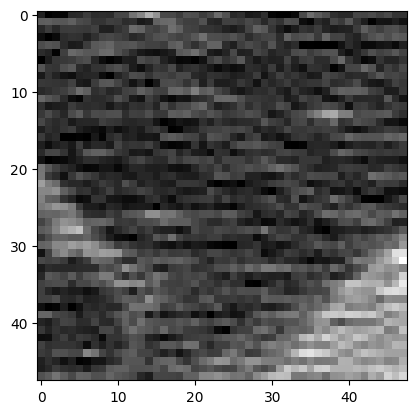

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(ct_chunk[24, :, :], cmap='gray')
plt.show()

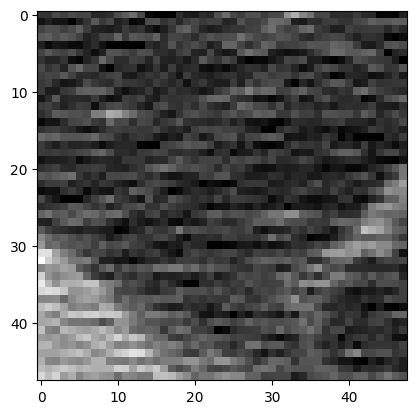

In [ ]:
flip_chunk = torch.flip(ct_chunk, [2])
plt.imshow(flip_chunk[24, :, :], cmap='gray')
plt.show()

torch.Size([32, 48, 48])


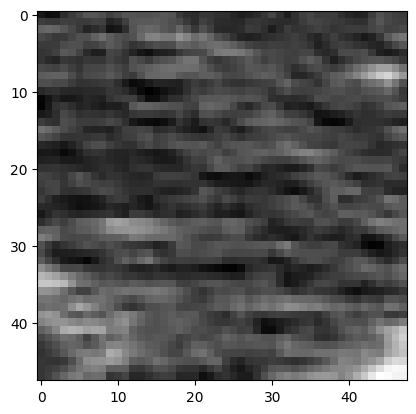

In [ ]:
from torchvision.transforms import Resize, CenterCrop
scale = 1.5
new_size = int(48 * scale)

resize_fn = Resize(new_size)
scaled_chunk = resize_fn(ct_chunk)

crop_fn = CenterCrop(size=(48, 48))
temp = crop_fn(scaled_chunk)

print(temp.shape)
plt.imshow(temp[24, :, :], cmap='gray')
plt.show()

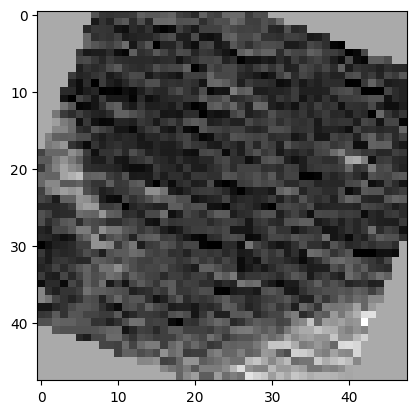

In [ ]:
from torchvision.transforms import RandomRotation
rotate_fn = RandomRotation(45)
rotated_chunk = rotate_fn(ct_chunk)
plt.imshow(rotated_chunk[24, :, :], cmap='gray')
plt.show()

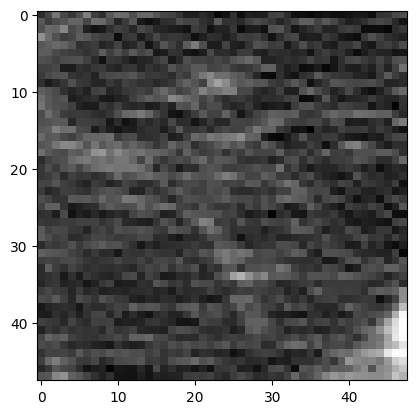

In [ ]:
from torchvision.transforms.v2 import GaussianNoise
noise_fn = GaussianNoise(sigma=50, clip=False)
new_chunk = noise_fn(ct_chunk[[8], :, :])
plt.imshow(new_chunk[0, :, :], cmap='gray')
plt.show()

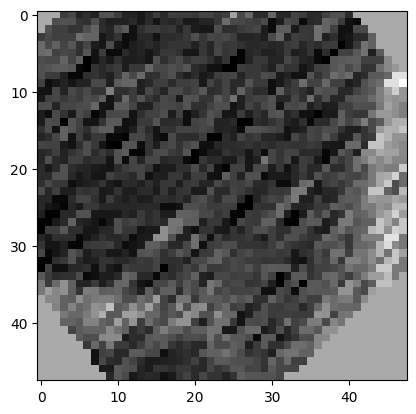

In [ ]:
from torchvision.transforms.v2 import RandomAffine
shift_fn = RandomAffine(degrees=45, translate=(0.1, 0.1),
                        scale=(0.8, 1.2),
                        shear=10)
shifted_chunk = shift_fn(ct_chunk)
plt.imshow(shifted_chunk[24, :, :], cmap='gray')
plt.show()

In [ ]:
num_positives = 100
copies = 25
num_negatives = 2500
num_nodules = num_positives + num_negatives

chunks = torch.zeros([num_nodules, 32, 48, 48])
labels = torch.zeros([num_nodules])

negative_chunks = torch.zeros([num_negatives, 32, 48, 48])
negative_labels = torch.zeros([num_negatives])

ids = data['seriesuid'].unique()
count = 0

for seriesuid in ids:

    mhd_path = "subset0/" + seriesuid + ".mhd"
    ct_mhd = sitk.ReadImage(mhd_path)
    ct_a = np.array(sitk.GetArrayFromImage(ct_mhd), dtype=np.float32)
    ct_a = ct_a.clip(-1000, 1000, ct_a)


    condition = (data['seriesuid'] == seriesuid)
    indices = data[condition].index

    for nodule_index in indices:


        if data.loc[nodule_index, "class"] == 1:
            continue


        index, row, col = data.loc[nodule_index, ["index", "row", "col"]]


        ct_chunk = torch.zeros([32, 48, 48])
        chunk = ct_a[(index-16):(index+16), (row-24):(row+24), (col-24):(col+24)]
        chunk_indices, chunk_rows, chunk_cols = chunk.shape
        ct_chunk[:chunk_indices, :chunk_rows, :chunk_cols] = torch.tensor(chunk)


        negative_chunks[count, :, : :] = ct_chunk


        negative_labels[count] = data.loc[nodule_index, "class"]


        count += 1


        if count % 100 == 0:
            print("Number of negative nodules constructed:", count)


        if count == num_negatives:
            break

    if count == num_negatives:
        break

Number of negative nodules constructed: 100
Number of negative nodules constructed: 200
Number of negative nodules constructed: 300
Number of negative nodules constructed: 400
Number of negative nodules constructed: 500
Number of negative nodules constructed: 600
Number of negative nodules constructed: 700
Number of negative nodules constructed: 800
Number of negative nodules constructed: 900
Number of negative nodules constructed: 1000
Number of negative nodules constructed: 1100
Number of negative nodules constructed: 1200
Number of negative nodules constructed: 1300
Number of negative nodules constructed: 1400
Number of negative nodules constructed: 1500
Number of negative nodules constructed: 1600
Number of negative nodules constructed: 1700
Number of negative nodules constructed: 1800
Number of negative nodules constructed: 1900
Number of negative nodules constructed: 2000
Number of negative nodules constructed: 2100
Number of negative nodules constructed: 2200
Number of negative 

In [ ]:
positive_chunks = torch.zeros([num_positives * copies, 32, 48, 48])
positive_labels = torch.zeros([num_positives * copies])
count = 0

shift_fn = RandomAffine(degrees=45, translate=(0.1, 0.1), shear=10)

for seriesuid in ids:

    mhd_path = "subset0/" + seriesuid + ".mhd"
    ct_mhd = sitk.ReadImage(mhd_path)
    ct_a = np.array(sitk.GetArrayFromImage(ct_mhd), dtype=np.float32)
    ct_a = ct_a.clip(-1000, 1000, ct_a)


    condition = (data['seriesuid'] == seriesuid)
    indices = data[condition].index

    for nodule_index in indices:


        if data.loc[nodule_index, "class"] == 0:
            continue


        index, row, col = data.loc[nodule_index, ["index", "row", "col"]]


        ct_chunk = torch.zeros([32, 48, 48])
        chunk = ct_a[(index-16):(index+16), (row-24):(row+24), (col-24):(col+24)]
        chunk_indices, chunk_rows, chunk_cols = chunk.shape
        ct_chunk[:chunk_indices, :chunk_rows, :chunk_cols] = torch.tensor(chunk)


        positive_chunks[count, :, : :] = ct_chunk


        positive_labels[count] = data.loc[nodule_index, "class"]


        for i in range(1, copies):
            shifted_chunk = shift_fn(ct_chunk)
            positive_chunks[count + num_positives * i, :, :, :] = shifted_chunk
            positive_labels[count + num_positives * i] = 1


        count += 1


        if count % 10 == 0:
            print("Number of positive nodules constructed:", count * copies)


        if count == num_positives:
            break

    if count == num_positives:
        break

Number of positive nodules constructed: 250
Number of positive nodules constructed: 500
Number of positive nodules constructed: 750
Number of positive nodules constructed: 1000
Number of positive nodules constructed: 1250
Number of positive nodules constructed: 1500
Number of positive nodules constructed: 1750
Number of positive nodules constructed: 2000
Number of positive nodules constructed: 2250
Number of positive nodules constructed: 2500


In [ ]:
chunks = torch.cat([negative_chunks, positive_chunks], dim=0)
labels = torch.cat([negative_labels, positive_labels], dim=0)
print(chunks.shape, labels.shape)

torch.Size([5000, 32, 48, 48]) torch.Size([5000])


In [ ]:
#print(labels[labels == 0].shape)
#print(labels[labels == 1].shape)

6.2 Retrain the neural network model on the new training set.

In [ ]:
del positive_chunks, negative_chunks

In [ ]:
number_input_values = 32 * 48 * 48
#print(number_input_values)

In [ ]:
chunks_train, chunks_test, labels_train, labels_test = train_test_split(chunks, labels, test_size=0.2)
print(chunks_train.shape, labels_train.shape)
print(chunks_test.shape, labels_test.shape)

model = nn.Sequential(

            nn.Flatten(),
            nn.Linear(number_input_values, 2),
            nn.LogSoftmax(dim=1))

print(model)

learning_rate = 1e-2

optimizer = optim.SGD(model.parameters(), lr=learning_rate)

loss_fn = nn.NLLLoss()


dataset = torch.utils.data.TensorDataset(chunks_train, labels_train)
train_loader = torch.utils.data.DataLoader(dataset, batch_size=64,
                                           shuffle=True)

n_epochs = 70

losses = []

for epoch in range(n_epochs):
    total_loss = 0.0
    for img, label in train_loader:
        out = model(img)
        loss = loss_fn(out, label.long())
        total_loss += loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch: %d, Loss: %f" % (epoch, float(total_loss / num_nodules)))
    losses.append(float(total_loss /num_nodules))

torch.Size([4000, 32, 48, 48]) torch.Size([4000])
torch.Size([1000, 32, 48, 48]) torch.Size([1000])
Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=73728, out_features=2, bias=True)
  (2): LogSoftmax(dim=1)
)
Epoch: 0, Loss: 334085.718750
Epoch: 1, Loss: 33724.703125
Epoch: 2, Loss: 50592.175781
Epoch: 3, Loss: 65360.898438
Epoch: 4, Loss: 73257.117188
Epoch: 5, Loss: 23339.966797
Epoch: 6, Loss: 23426.324219
Epoch: 7, Loss: 17353.894531
Epoch: 8, Loss: 58985.167969
Epoch: 9, Loss: 19100.765625
Epoch: 10, Loss: 13031.726562
Epoch: 11, Loss: 12286.324219
Epoch: 12, Loss: 90956.937500
Epoch: 13, Loss: 13430.946289
Epoch: 14, Loss: 81407.640625
Epoch: 15, Loss: 15737.262695
Epoch: 16, Loss: 14807.975586
Epoch: 17, Loss: 10558.365234
Epoch: 18, Loss: 13500.954102
Epoch: 19, Loss: 10876.996094
Epoch: 20, Loss: 8996.675781
Epoch: 21, Loss: 7218.366699
Epoch: 22, Loss: 7229.359863
Epoch: 23, Loss: 5919.895508
Epoch: 24, Loss: 7508.497070
Epoch: 25, Loss: 5786.973

In [ ]:
probabilities = model(chunks_test)
_, predictions = torch.max(probabilities, dim=1)
mat = confusion_matrix(labels_test, predictions)
print(mat)

[[483  28]
 [ 21 468]]


6.3 Perform model evaluation and compare the performance of the new model to the old model.

In [ ]:
dataset = torch.utils.data.TensorDataset(chunks_test, labels_test)
test_loader = torch.utils.data.DataLoader(dataset, batch_size=64,
                                           shuffle=True)

In [ ]:
probabilities = model(chunks_test)
probabilities

tensor([[-85361792.,         0.],
        [        0., -13128478.],
        [        0., -39347020.],
        ...,
        [        0., -38044052.],
        [        0., -32238432.],
        [-29312692.,         0.]], grad_fn=<LogSoftmaxBackward0>)

In [ ]:
_, predictions = torch.max(probabilities, dim=1)
predictions[:50]

tensor([1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0,
        1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0,
        0, 0])

In [ ]:
acc = accuracy_score(labels_test, predictions)
print("Accuracy:", acc)

Accuracy: 0.951


In [ ]:
for positive_class in range(10):
    precision = precision_score(test_labels, predictions, average=None, labels=[positive_class])
    recall = recall_score(test_labels, predictions, average=None, labels=[positive_class])
    print(dataset[positive_class], precision, recall)

(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        ...,

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: Undefine

In [ ]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(labels_test, predictions)
print(mat)

[[483  28]
 [ 21 468]]


In [ ]:
from sklearn.metrics import precision_score, recall_score
precision = precision_score(labels_test, predictions)
print("Precision:", precision)

recall = recall_score(labels_test, predictions)
print("Recall:", recall)

Precision: 0.9435483870967742
Recall: 0.9570552147239264


In [ ]:
print(labels[labels == 0].shape)
print(labels[labels == 1].shape)

torch.Size([2500])
torch.Size([2500])


The performance of this model does way better than the last one because it manages to make set the numbers of the classes into equal amounts and gave us sets of nearly balanced values for accuracy, precision, confusion matrix, and recall. Moreover, they all gave higher predictions due their percentages especially precision and recall. Finally, the true positives and negatives are shown to way higher than the negative ones.